# Regime & Risk: Where a Calibrated Trading-Book Risk Measure Holds, and Where It Doesn't

**The model is well calibrated unconditionally, and not conditionally — and we have measured
exactly where, how strongly, and how robustly.**

This notebook consumes the persisted outputs of `backtest.py`, `evaluate_reliability.py`,
`calibrate_conformal.py`, and `compute_risk.py`. It computes nothing new except two
diagnostic calls, `breakdown_point` and `breakdown_quantiles`, that group already-computed
forecasts by already-computed regime flags. Every number below traces back to a committed CSV,
parquet file, or MLflow run — see each table/figure caption for its source.

## 0. Setup

The following cells set up the plotting. They are frontmatter for convenience and reproducibility. Scroll down to "1. Executive summary" for results and plots.

In [6]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from IPython.display import HTML
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from energy_price_forecast.data.loaders import load_interim_hourly, load_processed_features
from energy_price_forecast.evaluation.backtest import day_breach_series
from energy_price_forecast.evaluation.breakdown import breakdown_point, breakdown_quantiles
from energy_price_forecast.evaluation.config import (
    CALIBRATION_EXPERIMENT_NAME,
    BacktestConfig,
    RegimeConfig,
)
from energy_price_forecast.evaluation.regimes import (
    MACRO_REGIME_COLUMN,
    REGIME_FLAG_COLUMNS,
    tag_regimes,
)
from energy_price_forecast.evaluation.reliability import FORECAST_LEVEL_BUCKETS
from energy_price_forecast.market_time import LOCAL_TZ

DATA = Path("../data/processed")
INTERIM = Path("../data/interim/hourly.parquet")

plt.rcParams.update(
    {
        "figure.dpi": 85,
        "savefig.dpi": 85,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    }
)
%matplotlib inline

In [7]:
# --- Plot library cell (spec 4.5, 2.2) --------------------------------------
# All plot functions are PURE: data comes in as arguments, nothing is read
# from a global, nothing is plt.show()-n, every function returns a Figure via
# plt.subplots(...). This is deliberate: a function that returns a Figure
# drops into Streamlit's st.pyplot(fig) unchanged in Sprint 5; one that calls
# plt.show() and touches global pyplot state does not (spec 2.2).

VARIANT_COLORS: dict[str, str] = {
    "raw": "#9e9e9e",
    "calibrated": "#1f77b4",
    "fhs": "#ff7f0e",
}
SIDE_MARKERS: dict[str, str] = {"long": "o", "short": "s"}
MODEL_COLORS: dict[str, str] = {
    "similarday_naive": "#9e9e9e",
    "lasso": "#2ca02c",
    "lightgbm": "#1f77b4",
    "arimax": "#d62728",
}
ZONE_COLORS: dict[str, str] = {"green": "#2ca02c", "yellow": "#f1c232", "red": "#cc0000"}
LOW_SUPPORT_LABEL = "open marker = low support; the CI is illustrative, not inferential"
RAW_LABEL = "raw = counterfactual (uncalibrated q05 has no tail), never a validated variant"


def plot_regime_breakdown(tables: dict[str, pd.DataFrame], *, metric: str = "mae") -> Figure:
    """F1. Grouped bars: one group per regime, one bar per model, height = `metric`.

    `tables` maps model name -> the `breakdown_point` frame for that model.
    Annotates each regime group with its hour count `n` (thin regimes must be
    visibly thin -- an MAE over 40 hours is noise and the reader must see that).
    """
    regimes = list(next(iter(tables.values())).index)
    models = list(tables.keys())
    n_models = len(models)
    x = np.arange(len(regimes))
    width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for i, model in enumerate(models):
        heights = tables[model][metric].to_numpy()
        offset = (i - (n_models - 1) / 2) * width
        ax.bar(
            x + offset,
            heights,
            width=width,
            label=model,
            color=MODEL_COLORS.get(model, None),
        )
    ns = tables[models[0]]["n"].to_numpy()
    y_top = max(tables[m][metric].max() for m in models)
    for xi, n in zip(x, ns, strict=True):
        ax.annotate(
            f"n={int(n):,}",
            (xi, y_top * 1.02),
            ha="center",
            va="bottom",
            fontsize=7,
            color="#555555",
        )
    ax.set_xticks(x)
    ax.set_xticklabels(regimes, rotation=30, ha="right")
    ax.set_ylabel(metric.upper())
    ax.set_title("Point-accuracy breakdown by regime")
    ax.legend(loc="upper left", ncols=n_models)
    fig.tight_layout()
    return fig


def plot_reliability(curves: dict[str, pd.DataFrame], *, levels: list[float]) -> Figure:
    """F2. Reliability diagram: nominal vs empirical coverage, ideal diagonal.

    `curves` maps artefact label ("raw", "calibrated_sorted", "arimax") -> a
    frame indexed by `level` with an `empirical` column. ARIMAX is drawn as a
    pale reference curve, never as a competitor.
    """
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1, label="ideal")
    styles = {
        "raw": {"color": VARIANT_COLORS["raw"], "marker": "o"},
        "calibrated_sorted": {"color": VARIANT_COLORS["calibrated"], "marker": "o"},
        "arimax": {"color": MODEL_COLORS["arimax"], "marker": "^", "alpha": 0.45},
    }
    for label, frame in curves.items():
        style = styles.get(label, {})
        ax.plot(
            frame.index,
            frame["empirical"],
            label=label,
            linewidth=2 if label != "arimax" else 1.5,
            **style,
        )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("nominal one-sided coverage")
    ax.set_ylabel("empirical one-sided coverage")
    ax.set_title("Reliability: nominal vs. empirical coverage")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig


def plot_fan_chart(
    quantiles: dict[float, pd.Series], y_true: pd.Series, *, title: str, ax: Axes | None = None
) -> Figure:
    """F4/F3 building block. Nested quantile bands (0.05-0.95, 0.10-0.90, 0.25-0.75)
    with the realised price on top. Accepts an optional `ax` so the 2x2
    before/after grid can reuse it. Returns the parent Figure.
    """
    owns_fig = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 3.2))
    else:
        fig = ax.figure
    idx = y_true.index
    bands = [(0.05, 0.95, 0.15), (0.10, 0.90, 0.25), (0.25, 0.75, 0.4)]
    for lo, hi, alpha in bands:
        if lo in quantiles and hi in quantiles:
            ax.fill_between(
                idx,
                quantiles[lo].reindex(idx),
                quantiles[hi].reindex(idx),
                color=VARIANT_COLORS["calibrated"],
                alpha=alpha,
                linewidth=0,
            )
    if 0.5 in quantiles:
        ax.plot(idx, quantiles[0.5].reindex(idx), color=VARIANT_COLORS["calibrated"], linewidth=1)
    ax.plot(idx, y_true, color="black", linewidth=1.3, label="realised price")
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("EUR/MWh")
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")
    if owns_fig:
        fig.tight_layout()
    return fig


def plot_pnl_distribution(book: pd.DataFrame, thresholds: pd.DataFrame) -> Figure:
    """F4. Two panels (long, short): histogram of realised P&L with the MEAN VaR and
    ES threshold of each variant as vertical lines. Makes "raw has no tail"
    visible in one glance: its threshold sits inside the bulk of the distribution.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, side, col in zip(axes, ["long", "short"], ["pnl_long", "pnl_short"], strict=True):
        ax.hist(book[col], bins=80, color="#cccccc", edgecolor="none")
        sub = thresholds[thresholds["side"] == side]
        for _, row in sub.iterrows():
            color = VARIANT_COLORS[row["variant"]]
            ax.axvline(-row["mean_var"], color=color, linestyle="--", linewidth=1.5)
            ax.axvline(
                -row["mean_es"],
                color=color,
                linestyle="-",
                linewidth=1.5,
                label=f"{row['variant']} (VaR dashed, ES solid)",
            )
        ax.set_title(f"{side} book P&L")
        ax.set_xlabel("EUR / MWh-hour")
    axes[0].set_ylabel("hours")
    axes[1].legend(loc="upper left", fontsize=8)
    fig.suptitle("Realised P&L vs. mean VaR/ES thresholds by variant")
    fig.tight_layout()
    return fig


def plot_es_timeseries(risk: pd.DataFrame) -> Figure:
    """F5. ES(t) over the test period, calibrated vs fhs, both sides."""
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    for ax, side in zip(axes, ["long", "short"], strict=True):
        for variant in ("calibrated", "fhs"):
            sub = risk[(risk["variant"] == variant) & (risk["side"] == side)].sort_values(
                "timestamp"
            )
            daily = sub.set_index("timestamp")["es"].resample("1D").mean()
            ax.plot(daily.index, daily, color=VARIANT_COLORS[variant], label=variant, linewidth=1)
        ax.set_title(f"{side} book", fontsize=9)
        ax.set_ylabel("ES (EUR/MWh, daily mean)")
    axes[0].legend(loc="upper right")
    fig.suptitle("ES(t): calibrated vs. fhs")
    fig.tight_layout()
    return fig


def plot_coverage_forest(coverage: pd.DataFrame, *, alpha: float) -> Figure:
    """F6. The signature figure of the model validation -- forest plot of breach_rate with bootstrap CI, one row
    per (variant, side, subset), vertical reference line at `alpha`.

    Rows whose CI excludes alpha are highlighted. `low_support` rows get an OPEN
    marker and a DASHED CI bar -- never dropped (spec 2.4). `raw` rows are drawn
    greyed and labelled as the counterfactual they are.
    """
    subsets = list(dict.fromkeys(coverage["subset"]))
    combos = [("calibrated", "long"), ("calibrated", "short"), ("fhs", "long"), ("fhs", "short")]
    n_sub = len(subsets)
    row_h = 0.85
    fig, ax = plt.subplots(figsize=(9, 0.42 * n_sub * len(combos) + 1.5))

    y = 0
    yticks: list[float] = []
    yticklabels: list[str] = []
    for subset in subsets:
        y0 = y
        for variant, side in combos:
            row = coverage[
                (coverage["subset"] == subset)
                & (coverage["variant"] == variant)
                & (coverage["side"] == side)
            ]
            if row.empty:
                y += 1
                continue
            r = row.iloc[0]
            low_support = bool(r["low_support"])
            excludes = r.get("breach_rate_ci_excludes_alpha")
            color = VARIANT_COLORS[variant]
            marker = SIDE_MARKERS[side]
            facecolor = color if not low_support else "none"
            linestyle = "dashed" if low_support else "solid"
            if pd.notna(r["breach_rate_ci_low"]):
                ax.plot(
                    [r["breach_rate_ci_low"], r["breach_rate_ci_high"]],
                    [y, y],
                    color=color,
                    linewidth=2.2 if excludes is True else 1.2,
                    linestyle=linestyle,
                    alpha=0.9,
                )
            ax.scatter(
                [r["breach_rate"]],
                [y],
                marker=marker,
                facecolor=facecolor,
                edgecolor=color,
                s=32,
                zorder=3,
            )
            raw_row = coverage[
                (coverage["subset"] == subset)
                & (coverage["variant"] == "raw")
                & (coverage["side"] == side)
            ]
            if not raw_row.empty and variant == "calibrated":
                ax.scatter(
                    [raw_row.iloc[0]["breach_rate"]],
                    [y],
                    marker=marker,
                    facecolor="none",
                    edgecolor=VARIANT_COLORS["raw"],
                    s=20,
                    zorder=2,
                    linestyle="dotted",
                )
            y += 1
        yticks.append((y0 + y - 1) / 2)
        yticklabels.append(subset)
        y += 0.6

    ax.axvline(alpha, color="black", linewidth=1, linestyle="--", zorder=1)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.invert_yaxis()
    ax.set_xlabel("breach_rate")
    ax.set_title(f"Coverage forest plot (reference line at alpha={alpha:.2f})")
    handles = [
        plt.Line2D([0], [0], color=VARIANT_COLORS["calibrated"], marker="o", label="calibrated, long"),
        plt.Line2D([0], [0], color=VARIANT_COLORS["calibrated"], marker="s", label="calibrated, short"),
        plt.Line2D([0], [0], color=VARIANT_COLORS["fhs"], marker="o", label="fhs, long"),
        plt.Line2D([0], [0], color=VARIANT_COLORS["fhs"], marker="s", label="fhs, short"),
        plt.Line2D([0], [0], color=VARIANT_COLORS["raw"], marker="o", linestyle="dotted", label="raw (counterfactual)"),
        plt.Line2D([0], [0], color="grey", marker="o", markerfacecolor="none", linestyle="dashed", label=LOW_SUPPORT_LABEL),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=7, ncols=1)
    fig.tight_layout()
    return fig


def plot_breach_calendar(day_breach: pd.Series, *, title: str) -> Figure:
    """F7. Calendar heatmap of DAY-level breaches (rows = weeks, cols = weekday).
    Makes the Christoffersen LR_ind of 53-104 VISIBLE: the reader sees the
    multi-day clusters instead of being told a number.
    """
    idx = pd.DatetimeIndex(day_breach.index)
    start = idx.min() - pd.Timedelta(days=int(idx.min().dayofweek))
    end = idx.max()
    full_range = pd.date_range(start, end, freq="D")  # inherits tz from start/end already
    series = day_breach.reindex(full_range)
    n_weeks = int(np.ceil(len(full_range) / 7))
    grid = np.full((n_weeks, 7), np.nan)
    for i, day in enumerate(full_range):
        week, dow = divmod(i, 7)
        val = series.iloc[i]
        grid[week, dow] = float(val) if pd.notna(val) else np.nan

    fig, ax = plt.subplots(figsize=(10, max(2.5, n_weeks * 0.045)))
    cmap = plt.get_cmap("Greys").copy()
    cmap.set_bad("#f0f0f0")
    masked = np.ma.masked_invalid(grid)
    ax.imshow(masked, aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="none")
    ax.set_xticks(range(7))
    ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    ax.set_yticks([])
    ax.set_ylabel(f"{n_weeks} weeks, top = earliest")
    ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_basel_traffic_light(windows: pd.DataFrame) -> Figure:
    """F8. Tile grid: 6 non-overlapping windows x (variant, side), coloured by zone.
    Caption carries BOTH caveats: illustrative zone bounds (95%/hourly, not the
    canonical 99%/250-day mapping) AND overdispersion (bounds too tight because
    hours are not independent).
    """
    combos = [
        ("raw", "long"),
        ("raw", "short"),
        ("calibrated", "long"),
        ("calibrated", "short"),
        ("fhs", "long"),
        ("fhs", "short"),
    ]
    n_windows = int(windows["window_index"].max()) + 1
    fig, ax = plt.subplots(figsize=(1.1 * n_windows + 2, 0.55 * len(combos) + 1))
    for row, (variant, side) in enumerate(combos):
        sub = windows[(windows["variant"] == variant) & (windows["side"] == side)].sort_values(
            "window_index"
        )
        for _, w in sub.iterrows():
            ax.add_patch(
                plt.Rectangle(
                    (w["window_index"], row),
                    1,
                    1,
                    facecolor=ZONE_COLORS[w["zone"]],
                    edgecolor="white",
                )
            )
    ax.set_xlim(0, n_windows)
    ax.set_ylim(0, len(combos))
    ax.set_xticks(np.arange(n_windows) + 0.5)
    ax.set_xticklabels([f"W{i}" for i in range(n_windows)])
    ax.set_yticks(np.arange(len(combos)) + 0.5)
    ax.set_yticklabels([f"{v}/{s}" for v, s in combos])
    ax.invert_yaxis()
    ax.set_title("Basel traffic light: non-overlapping 250-day windows")
    fig.tight_layout()
    return fig


def plot_block_sensitivity(sensitivity: pd.DataFrame) -> Figure:
    """F9. ci_width_ratio vs block_days: median and max in bold, individual cells as
    faint background lines. One sentence of caption: significance is not effect
    size -- the dependence is certain (LR 53-104) and costs ~19% of effective
    sample size.
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    key = ["variant", "side", "subset"]
    for _, cell in sensitivity.groupby(key):
        cell = cell.sort_values("block_days")
        ax.plot(cell["block_days"], cell["ci_width_ratio"], color="#cccccc", linewidth=0.6, zorder=1)
    agg = sensitivity.groupby("block_days")["ci_width_ratio"].agg(["median", "max"])
    ax.plot(agg.index, agg["median"], color=VARIANT_COLORS["calibrated"], linewidth=2.5, marker="o", label="median", zorder=3)
    ax.plot(agg.index, agg["max"], color="#cc0000", linewidth=2, marker="o", label="max", zorder=3)
    ax.axhline(1.0, color="black", linewidth=1, linestyle=":")
    ax.set_xlabel("block_days")
    ax.set_ylabel("ci_width_ratio (relative to block_days=1)")
    ax.set_title("Block-bootstrap sensitivity")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig

**Files consumed below:** each loader line names its source; each
downstream table/figure caption repeats the file it came from.

In [8]:
def _require(path: Path, cmd: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found -- generate it first with:\n  {cmd}")
    return path


# --- 4.1: regime flags on the full interim index ---------------------------
interim = load_interim_hourly(INTERIM)
regime_config = RegimeConfig()
regimes = tag_regimes(interim, regime_config)

# --- Sprint 2/3: point + quantile predictions, exact files verified 2026-07-14 ---
preds_point = {
    "similarday_naive": pd.read_parquet(
        _require(DATA / "backtest_similarday.parquet", "uv run python scripts/backtest.py --model naive")
    ),
    "lasso": pd.read_parquet(
        _require(DATA / "backtest_lasso.parquet", "uv run python scripts/backtest.py --model lasso")
    ),
    "lightgbm": pd.read_parquet(
        _require(
            DATA / "preds_lgbm_q50.parquet",
            "uv run python scripts/backtest.py --model lgbm --alpha 0.5 --window rolling "
            "--train-span-days 90 --refit-every 1 --study lgbm_quantile_grid "
            "--out data/processed/preds_lgbm_q50.parquet",
        )
    ),
    "arimax": pd.read_parquet(
        _require(
            DATA / "preds_arimax_v2_q50.parquet",
            "uv run python scripts/backtest.py --model arimax --alpha 0.5 --train-span-days 90 "
            "--refit-every 7 --study arimax_benchmark_v2 --out data/processed/preds_arimax_v2_q50.parquet",
        )
    ),
}

lgbm_quantiles_raw = {
    a: pd.read_parquet(_require(DATA / f"preds_lgbm_q{int(a * 100):02d}.parquet", "uv run python scripts/backtest.py --model lgbm"))["y_pred"]
    for a in (0.05, 0.5, 0.95)
}
arimax_quantiles_raw = {
    a: pd.read_parquet(
        _require(DATA / f"preds_arimax_v2_q{int(a * 100):02d}.parquet", "uv run python scripts/backtest.py --model arimax")
    )["y_pred"]
    for a in (0.05, 0.5, 0.95)
}
y_true_lgbm = pd.read_parquet(DATA / "preds_lgbm_q50.parquet")["y_true"]
y_true_arimax = pd.read_parquet(DATA / "preds_arimax_v2_q50.parquet")["y_true"]

# --- 4.3a: raw reliability curves (LightGBM + ARIMAX) -----------------------
reliability_curve_raw = pd.read_csv(
    _require(DATA / "reliability_curve.csv", "uv run python scripts/evaluate_reliability.py")
)

# --- 4.3b/c: conformal reliability (LightGBM only), bands, diagnostics -----
conformal_reliability = {
    variant: pd.read_csv(
        _require(
            DATA / f"conformal_reliability_{variant}.csv",
            "uv run python scripts/calibrate_conformal.py",
        )
    )
    for variant in ("raw", "calibrated", "sorted")
}
conformal_diagnostics = pd.read_csv(
    _require(DATA / "conformal_diagnostics.csv", "uv run python scripts/calibrate_conformal.py")
)

# --- 4.3b/c: the seven calibrated_sorted quantile bands, for the fan charts ---
QUANTILE_LEVELS = (0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95)
preds_calibrated_sorted = {
    a: pd.read_parquet(
        _require(
            DATA / f"preds_lgbm_q{int(a * 100):02d}_calibrated_sorted.parquet",
            "uv run python scripts/calibrate_conformal.py",
        )
    )["y_pred"]
    for a in QUANTILE_LEVELS
}
preds_raw_grid = {
    a: pd.read_parquet(
        _require(DATA / f"preds_lgbm_q{int(a * 100):02d}.parquet", "uv run python scripts/backtest.py --model lgbm")
    )["y_pred"]
    for a in QUANTILE_LEVELS
}
y_true_grid = pd.read_parquet(DATA / "preds_lgbm_q50.parquet")["y_true"]

# --- 4.4a: book, hourly risk measures, summary, FHS reliability check ------
book_hourly = pd.read_parquet(_require(DATA / "book_hourly.parquet", "uv run python scripts/compute_risk.py"))
risk_hourly = pd.read_parquet(_require(DATA / "risk_hourly.parquet", "uv run python scripts/compute_risk.py"))
risk_summary = pd.read_csv(_require(DATA / "risk_summary.csv", "uv run python scripts/compute_risk.py"))
risk_reliability_fhs = pd.read_csv(
    _require(DATA / "risk_reliability_fhs.csv", "uv run python scripts/compute_risk.py")
)

mlflow.set_tracking_uri("file:../mlruns")
_client = mlflow.tracking.MlflowClient()
_risk_run = _client.search_runs(
    [_client.get_experiment_by_name(CALIBRATION_EXPERIMENT_NAME).experiment_id],
    filter_string="tags.mlflow.runName = 'risk_measures'",
    order_by=["start_time DESC"],
    max_results=1,
)[0]
risk_metrics = _risk_run.data.metrics

# --- 4.4b (+ Nachtrag 1/2): backtest validation -----------------------------
backtest_coverage = pd.read_csv(
    _require(DATA / "backtest_coverage.csv", "uv run python scripts/backtest_risk.py")
)
backtest_variant_contrast = pd.read_csv(
    _require(DATA / "backtest_variant_contrast.csv", "uv run python scripts/backtest_risk.py")
)
backtest_descriptive_expost = pd.read_csv(
    _require(DATA / "backtest_descriptive_expost.csv", "uv run python scripts/backtest_risk.py")
)
backtest_basel_windows = pd.read_csv(
    _require(DATA / "backtest_basel_windows.csv", "uv run python scripts/backtest_risk.py"), comment="#"
)
backtest_block_sensitivity_coverage = pd.read_csv(
    _require(
        DATA / "backtest_block_sensitivity_coverage.csv",
        "uv run python scripts/backtest_block_sensitivity.py",
    )
)

backtest_config = BacktestConfig()
print("all artefacts loaded.")

all artefacts loaded.


In [9]:
# --- Guard cell (spec 4.5, 2.5/5.0): assertions only, "all checks passed" or crash ---
assert len(backtest_coverage) == 90, f"backtest_coverage.csv has {len(backtest_coverage)} rows, expected 90"
assert len(backtest_variant_contrast) == 30, f"backtest_variant_contrast.csv has {len(backtest_variant_contrast)} rows, expected 30"
assert len(risk_summary) == 6, f"risk_summary.csv has {len(risk_summary)} rows, expected 6"

_anchor = backtest_coverage[
    (backtest_coverage["variant"] == "calibrated")
    & (backtest_coverage["side"] == "long")
    & (backtest_coverage["subset"] == "overall")
]["breach_rate"].iloc[0]
assert abs(_anchor - 0.0489) < 1e-3, (
    f"overall/calibrated/long breach_rate={_anchor}, expected ~0.0489 -- "
    "backtest_coverage.csv looks stale, re-run scripts/backtest_risk.py"
)

_point_estimate_spread = backtest_block_sensitivity_coverage.groupby(
    ["variant", "side", "subset"]
)["breach_rate"].nunique()
assert (_point_estimate_spread == 1).all(), (
    "breach_rate varies across block_days in the sensitivity frame -- it must depend only on "
    "the data, never on the resampling regime (Nachtrag 2 invariant)"
)

print("all checks passed.")

all checks passed.


## 1. Executive summary

- **The counterfactual headline:** reporting the raw (or uncalibrated) q05 as a 5% VaR limit breaches in
  **18%** of hours, not 5%. The capital buffer implied by the raw quantile would have been
  **53–76% too small** (`buffer_factor` 1.53 long / 1.76 short, source: `risk_measures` MLflow
  run).
- **After conformal calibration, the risk measure is unconditionally well calibrated:**
  breach rates of 0.049 (long) / 0.052 (short), Kupiec does not reject at `overall` for either
  side (`backtest_coverage.csv`).
- **But it is not conditionally calibrated:** **35 of 60** validated (calibration variant, portfolio side, condition known at forecast time)
  cells break coverage even in the honest, day-block-bootstrapped test — not just the
  anti-conservative hourly chi-square (`backtest_coverage.csv`, `n_subsets_bootstrap_rejected`).
- **The mechanism is one thing wearing three faces:** conditional heteroskedasticity and
  regime persistence — concentrated in the evening ramp, Dunkelflaute, renewable-surplus, and
  visible directly as multi-day breach clustering (`chris_ind_lr` 53–104 on the day series).
- **Production recommendation: `calibrated`**, with the condition under which that choice
  flips (section 9).

## 2. Where the model wins and loses

**Point accuracy breaks down in exactly the regimes where money would be made and lost.**

In [10]:
point_tables = {name: breakdown_point(df, regimes) for name, df in preds_point.items()}

t1 = pd.concat(
    {name: tbl[["n", "mae", "rmse", "wape"]] for name, tbl in point_tables.items()}, axis=1
)
t1

similarday_naive                                  lasso  \
                                  n        mae       rmse      wape      n   
overall                       43802  34.771196  56.195774  0.290070  43802   
calm                           5831  13.749177  21.450378  0.219473   5831   
crisis                        13848  57.147521  81.644123  0.282572  13848   
post_crisis                   24123  27.007321  42.384053  0.312514  24123   
renewable_scarcity             3918  32.470777  58.821465  0.178691   3918   
high_wind                     12644  44.147391  65.431861  0.583679  12644   
negative_price                 1542  43.834903  60.553434  3.793463   1542   
price_spike                    2595  50.578844  81.075512  0.186746   2595   
normal                        24675  29.559623  49.035978  0.236643  24675   

                                                   lightgbm             \
                          mae       rmse      wape        n        mae   
overall             24.229616  38.398396  0.202130    43802  15.398778   
calm                 9.563336  13.240427  0.152656     5831   6.247650   
crisis              40.855058  57.305903  0.202012    13848  25.387094   
post_crisis         18.230775  27.380403  0.210956    24123  11.876913   
renewable_scarcity  28.001926  50.366135  0.154098     3918  21.765860   
high_wind           26.738263  39.554377  0.353511    12644  14.139599   
negative_price      22.562437  34.461859  1.952548     1542  13.043260   
price_spike         45.468885  73.154612  0.167879     2595  38.194727   
normal              21.168511  32.820614  0.169467    24675  13.784286   

                                        arimax                                  
                         rmse      wape      n        mae       rmse      wape  
overall             26.592558  0.128461  43802  22.866322  35.736993  0.190757  
calm                 8.913158  0.099729   5831   8.719943  11.757069  0.139193  
crisis              36.597010  0.125529  13848  32.379146  45.791298  0.160102  
post_crisis         22.270834  0.137433  24123  20.824866  32.891743  0.240974  
renewable_scarcity  45.018227  0.119780   3918  28.399243  56.432660  0.156284  
high_wind           20.458851  0.186942  12644  22.790781  30.923985  0.301320  
negative_price      27.414876  1.128761   1542  23.591557  35.223006  2.041608  
price_spike         63.508848  0.141022   2595  52.411962  82.224725  0.193514  
normal              22.389832  0.110352  24675  20.404039  30.313878  0.163347

In [11]:
lgbm_quantile_preds = {a: lgbm_quantiles_raw[a] for a in (0.05, 0.5, 0.95)}
arimax_quantile_preds = {a: arimax_quantiles_raw[a] for a in (0.05, 0.5, 0.95)}

quantile_tables = {
    "lightgbm": breakdown_quantiles(y_true_lgbm, lgbm_quantile_preds, regimes),
    "arimax": breakdown_quantiles(y_true_arimax, arimax_quantile_preds, regimes),
}
_t2_cols = ["n", "pinball_0.05", "pinball_0.50", "pinball_0.95", "interval_coverage_90", "interval_width_90"]
t2 = pd.concat({name: tbl[_t2_cols] for name, tbl in quantile_tables.items()}, axis=1)
t2

lightgbm                                         \
                          n pinball_0.05 pinball_0.50 pinball_0.95   
overall               43802     2.850476     7.699389     3.572399   
calm                   5831     1.100003     3.123825     1.722159   
crisis                13848     4.917051    12.693547     6.312092   
post_crisis           24123     2.087266     5.938456     2.446897   
renewable_scarcity     3918     2.748280    10.882930     6.510232   
high_wind             12644     2.953671     7.069800     2.584922   
negative_price         1542     5.437353     6.521630     2.228301   
price_spike            2595     4.432332    19.097363    14.438731   
normal                24675     2.614316     6.892143     3.011133   

                                                          arimax               \
                   interval_coverage_90 interval_width_90      n pinball_0.05   
overall                        0.637870         43.455649  43802     3.715949   
calm                           0.616704         16.823370   5831     1.536796   
crisis                         0.606802         71.083795  13848     6.684576   
post_crisis                    0.660822         34.033034  24123     2.538528   
renewable_scarcity             0.679684         60.867134   3918     2.851798   
high_wind                      0.626780         40.969166  12644     3.650690   
negative_price                 0.577821         51.083220   1542     7.860078   
price_spike                    0.557611        103.861043   2595     3.687013   
normal                         0.643283         37.900914  24675     3.727833   

                                                                   \
                   pinball_0.50 pinball_0.95 interval_coverage_90   
overall               11.433161     8.465330             0.503288   
calm                   4.359972     3.066729             0.482593   
crisis                16.189573    10.456563             0.492418   
post_crisis           10.412433     8.627195             0.514530   
renewable_scarcity    14.199622    15.137318             0.528331   
high_wind             11.395390     7.893692             0.481810   
negative_price        11.795779     5.070135             0.417639   
price_spike           26.205981    34.945415             0.217726   
normal                10.202020     6.453807             0.530659   

                                      
                   interval_width_90  
overall                    34.698959  
calm                       12.983751  
crisis                     48.645578  
post_crisis                31.941782  
renewable_scarcity         34.424896  
high_wind                  35.782414  
negative_price             32.734071  
price_spike                35.870617  
normal                     34.117707

**T1** (above): `evaluation.breakdown.breakdown_point` on the raw point predictions (`backtest_similarday.parquet` / `backtest_lasso.parquet` / `preds_lgbm_q50.parquet` / `preds_arimax_v2_q50.parquet`), sliced by the `regimes.py` flags. **T2** (above): `breakdown_quantiles` on the RAW (pre-calibration) LightGBM and ARIMAX quantiles at the three levels ARIMAX shares (q05/q50/q95) -- deliberately not calibrated, so this is an apples-to-apples raw comparison; the calibration story starts in section 3.

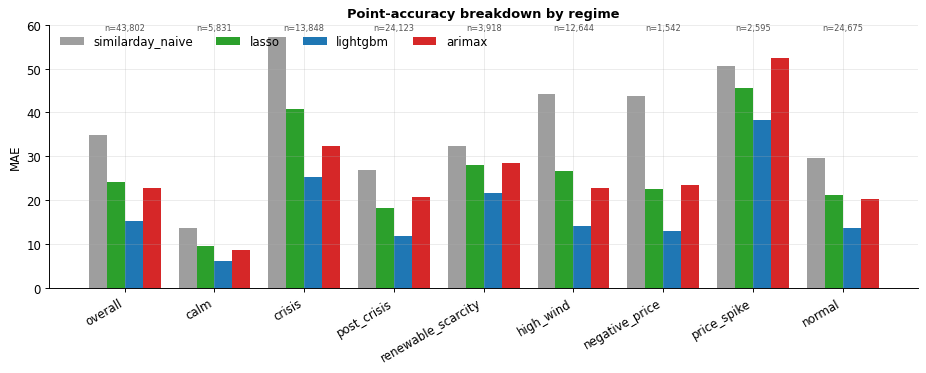

In [12]:
fig_f1 = plot_regime_breakdown(point_tables, metric="mae")

**Figure 1** (source: T1). LightGBM leads in every regime, but the *margin* over the naive baseline narrows in the crisis and scarcity regimes -- exactly where the model's edge would matter most for a trading book.

## 3. Are the intervals honest? Calibrating the raw quantiles.

**The raw quantiles systematically under-cover; the conformal layer repairs that -- on the
unconditional axis.**

**Two different calibration methods below -- worth separating once, here.**

`calibrate_conformal.py` recalibrates the raw LightGBM quantile grid directly: for each level,
a scaled/normalized conformal correction (`evaluation.conformal`) shifts the raw quantile by a
sigma-scaled offset, fitted on a rolling calibration window. `rearrangement.py` then sorts the
seven corrected levels per hour to remove ordering violations. The result is the
`calibrated` (= `calibrated_sorted`) quantile grid shown in Figure 2 and T3 below -- this is the
only variant whose own coverage is directly evidenced against realised prices.

Section 5 onward uses this calibrated grid for one of two trading-book risk thresholds, the
other being `fhs` (Filtered Historical Simulation): instead of trusting a calibrated quantile
directly, `fhs` standardises historical residuals `(price - mark) / sigma`, pools them in a
rolling 365-day window (`evaluation.residuals`), and reads the VaR/ES threshold off the
empirical tail of that pool. `calibrated` and `fhs` are two independent answers to the same
question -- one validated by direct quantile coverage, the other by internal consistency
between its own threshold and its own tail estimate -- and section 6 onward compares them
head-to-head. (A third, `raw`, uses the uncalibrated grid and appears only as a
counterfactual -- never a validated risk number, see section 5.)

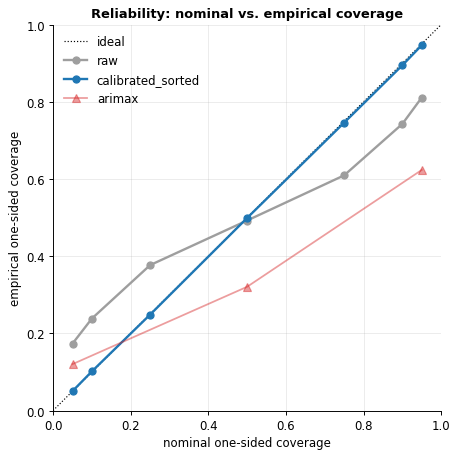

In [13]:
def _aggregate_reliability(frame: pd.DataFrame) -> pd.DataFrame:
    """n-weighted mean coverage per level, collapsing the forecast-height buckets."""
    weighted = frame.assign(_w=frame["coverage"] * frame["n"])
    grouped = weighted.groupby("level").agg(_w=("_w", "sum"), n=("n", "sum"))
    return pd.DataFrame({"empirical": grouped["_w"] / grouped["n"]})


reliability_curves_f2 = {
    "raw": _aggregate_reliability(conformal_reliability["raw"]),
    "calibrated_sorted": _aggregate_reliability(conformal_reliability["sorted"]),
    "arimax": _aggregate_reliability(reliability_curve_raw[reliability_curve_raw["model"] == "arimax"]),
}
fig_f2 = plot_reliability(reliability_curves_f2, levels=list(QUANTILE_LEVELS))

**Figure 2** (source: `conformal_reliability_raw.csv` / `conformal_reliability_sorted.csv` for LightGBM, `reliability_curve.csv` filtered to `model=="arimax"` for the pale reference curve; both are per-(bucket, level) and n-weighted-aggregated to a single per-level curve here). Raw LightGBM sits visibly below the diagonal (under-coverage); `calibrated_sorted` tracks it closely; ARIMAX shows the same under-coverage pattern, more pronounced.

In [14]:
_before = conformal_diagnostics["crossing_rate"].mean()
t3 = pd.DataFrame(
    {
        "stage": ["calibrated (pre-rearrangement)", "calibrated_sorted (post-rearrangement)"],
        "crossing_rate": [_before, 0.0],
        "source": [
            "conformal_diagnostics.csv (mean over all day/level rows)",
            "guaranteed by construction (evaluation/rearrangement.py: monotone isotonic "
            "projection per timestamp) -- not re-measured, Sprint 4.3c already established this",
        ],
    }
)
t3

,stage,crossing_rate,source
0,calibrated (pre-rearrangement),0.316153,conformal_diagnostics.csv (mean over all day/l...
1,calibrated_sorted (post-rearrangement),0.000000,guaranteed by construction (evaluation/rearran...


**T3** (above): the rearrangement step (`rearrangement.py`) turns a real 31.6% ordering-violation rate into a mathematical zero, without touching marginal coverage at any level (the sort is isotonic, so per-level empirical coverage in Figure 2 is unaffected). A crossing rate of 30% means that there is one crossing in the seven calculated quantiles (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95). The crossing rate of non-neighbouring quantiles is well under 1%.

## 4. What the bands look like, before and after

**Calibration buys coverage with width -- and specifically where it is needed.**

Episode selection rule: the FIRST episode in the test period with >=5
consecutive local-calendar days where at least one hour carries the flag (a "majority of
hours" bar turned out too strict -- checked against the real data, no Dunkelflaute run ever
reaches 5 days at a >=50%-of-hours threshold, only at a >=1-hour one). Deterministic, not
curated -- the alternative (hand-picking the most dramatic episode) would repeat the Basel
`basel_worst_zone` selection-bias mistake in miniature.

In [15]:
features_full = load_processed_features(DATA / "features.parquet")
# Restrict to the TEST period (y_true_grid's index) before searching for an episode --
# features.parquet also covers the pre-test training history (from 2020-01-08), and an
# episode found there would have no matching prediction to plot.
_features_test = features_full.reindex(y_true_grid.index)
_dunkelflaute_threshold = 1.0 - regime_config.renewable_scarcity_residual_share
_flag_dunkelflaute = _features_test["renewable_share_forecast"] < _dunkelflaute_threshold
_flag_surplus = _features_test["residual_load_forecast"] < backtest_config.surplus_forecast_residual_load_threshold


def _first_qualifying_episode(flag: pd.Series, *, min_run_days: int = 5, window_days: int = 10) -> tuple[pd.Timestamp, pd.Timestamp]:
    local_day = pd.DatetimeIndex(flag.index).tz_convert(LOCAL_TZ).normalize()
    daily = flag.groupby(local_day).mean() > 0.0
    daily = daily.sort_index()
    run_len = 0
    for day, is_flagged in daily.items():
        run_len = run_len + 1 if is_flagged else 0
        if run_len >= min_run_days:
            start = day - pd.Timedelta(days=min_run_days - 1)
            return start, start + pd.Timedelta(days=window_days)
    raise ValueError("no qualifying episode found")


dunkelflaute_start, dunkelflaute_end = _first_qualifying_episode(_flag_dunkelflaute)
surplus_start, surplus_end = _first_qualifying_episode(_flag_surplus)
print(f"Dunkelflaute episode: {dunkelflaute_start.date()} .. {dunkelflaute_end.date()}")
print(f"Surplus episode:      {surplus_start.date()} .. {surplus_end.date()}")

Dunkelflaute episode: 2021-02-27 .. 2021-03-09
Surplus episode:      2023-12-21 .. 2023-12-31


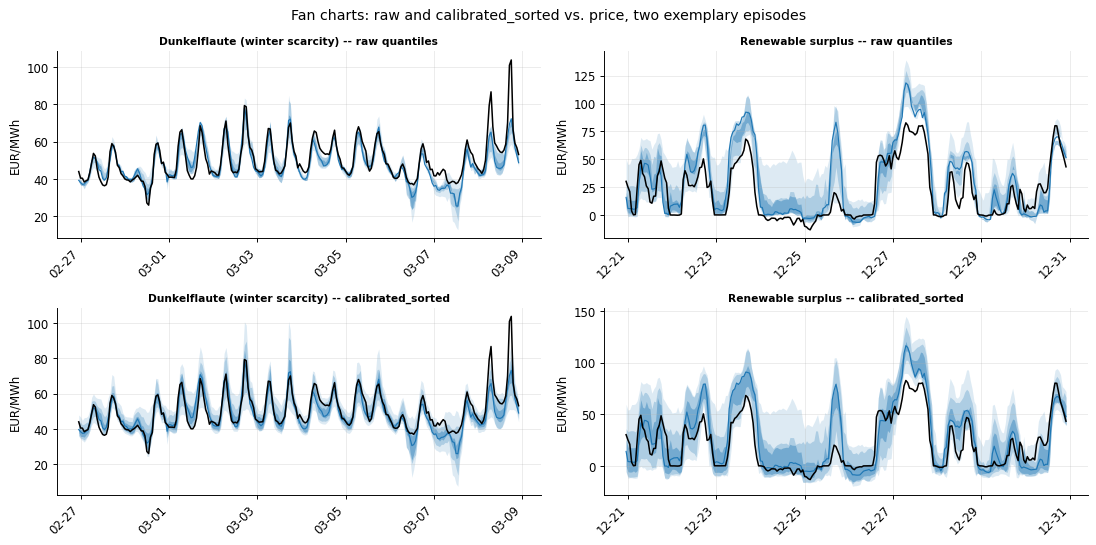

In [16]:
def _episode_slice(preds: dict[float, pd.Series], y_true: pd.Series, start: pd.Timestamp, end: pd.Timestamp) -> tuple[dict[float, pd.Series], pd.Series]:
    idx = y_true.index
    mask = (idx >= start.tz_convert(idx.tz)) & (idx < end.tz_convert(idx.tz))
    return {a: s.loc[mask] for a, s in preds.items()}, y_true.loc[mask]


fig_f3, axes_f3 = plt.subplots(2, 2, figsize=(13, 6.5), sharey=False)
for col, (label, start, end) in enumerate(
    [("Dunkelflaute (winter scarcity)", dunkelflaute_start, dunkelflaute_end), ("Renewable surplus", surplus_start, surplus_end)]
):
    raw_q, y_raw = _episode_slice(preds_raw_grid, y_true_grid, start, end)
    cal_q, y_cal = _episode_slice(preds_calibrated_sorted, y_true_grid, start, end)
    plot_fan_chart(raw_q, y_raw, title=f"{label} -- raw quantiles", ax=axes_f3[0, col])
    plot_fan_chart(cal_q, y_cal, title=f"{label} -- calibrated_sorted", ax=axes_f3[1, col])
fig_f3.suptitle("Fan charts: raw and calibrated_sorted vs. price, two exemplary episodes")
fig_f3.tight_layout()

**Figure 3** (source: `preds_lgbm_q{05..95}.parquet` / `preds_lgbm_q{05..95}_calibrated_sorted.parquet`). Top row: raw bands, systematically too narrow. Bottom row: calibrated_sorted bands widen -- visibly more in the Dunkelflaute episode (where the raw band misses the realised price outright) than in the surplus episode.

## 5. The counterfactual: what an uncalibrated risk number costs

**Reporting the raw q05 as a 5% limit breaches in 18% of hours instead of 5% -- the capital
buffer would have been more than half too small.**

In [17]:
t4 = risk_summary.copy()
t4["buffer_factor"] = t4.apply(
    lambda r: risk_metrics.get(f"buffer_factor_{r['side']}") if r["variant"] == "calibrated" else float("nan"),
    axis=1,
)
t4["skew_ratio"] = t4.apply(
    lambda r: risk_metrics.get("skew_ratio") if r["variant"] == "fhs" else float("nan"), axis=1
)
t4

,variant,side,mean_var,mean_es,mean_es_unclipped,breach_rate,mean_pi,clip_bind_rate,mean_clip_impact_es,es_ratio_conditional,realised_var_unconditional,realised_es_unconditional,n,buffer_factor,skew_ratio
0,raw,long,242.507697,399.133881,399.264058,0.182956,0.190412,0.009223,5.631203e-05,0.768763,355.251224,599.835914,43802.0,NaN,NaN
1,raw,short,233.674376,414.244596,414.244596,0.177582,0.191644,0.000000,1.037448e-17,0.886341,363.187814,677.052962,43802.0,NaN,NaN
2,calibrated,long,370.827136,542.583571,542.890765,0.048880,0.072723,0.009223,1.007327e-04,0.892006,355.251224,599.835914,43802.0,1.529136,NaN
3,calibrated,short,410.690136,611.855034,611.855034,0.051721,0.067360,0.000000,6.797133e-18,0.948291,363.187814,677.052962,43802.0,1.757532,NaN
4,fhs,long,347.342356,511.241052,511.311409,0.049034,0.050008,0.009223,4.402796e-05,0.988564,355.251224,599.835914,43802.0,NaN,1.161282
5,fhs,short,398.798338,593.776822,593.776822,0.049571,0.050008,0.000000,8.564973e-18,1.013606,363.187814,677.052962,43802.0,NaN,1.161282


**T4** (source: `risk_summary.csv` + the `risk_measures` MLflow run's `buffer_factor_*`/`skew_ratio` metrics). `buffer_factor` = `mean_var(calibrated) / mean_var(raw)` -- how much bigger the calibrated capital buffer is than the naive, uncalibrated one would have been; `skew_ratio` (fhs, scale-free) shows the short book's tail is heavier than the long book's.

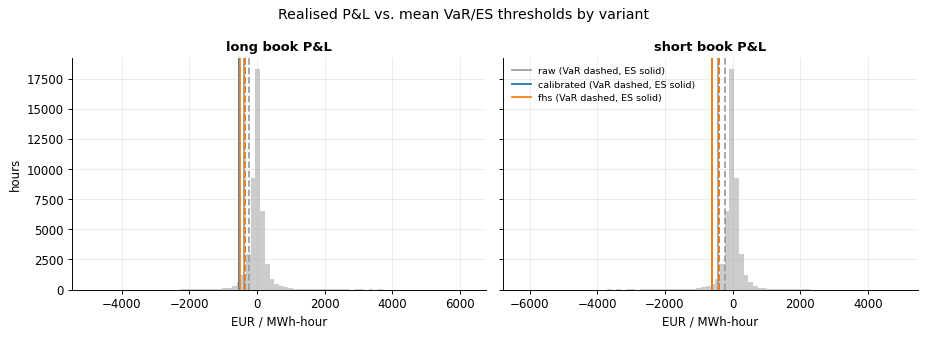

In [18]:
fig_f4 = plot_pnl_distribution(book_hourly, t4)

**Figure 4** (source: `book_hourly.parquet` + T4's mean thresholds). `raw`'s threshold sits inside the bulk of the P&L histogram -- visual confirmation of why it "has no tail": a raw, uncalibrated q05 is not an extreme-value estimate at all.

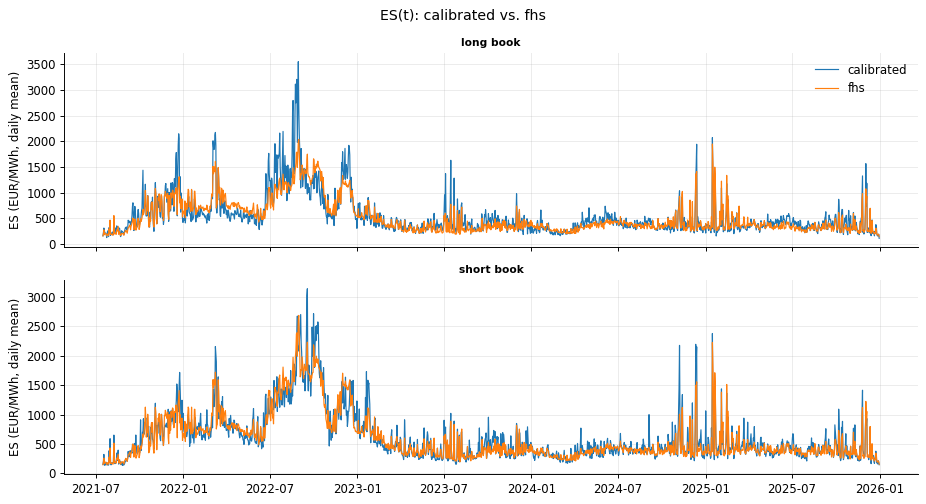

In [28]:
fig_f5 = plot_es_timeseries(risk_hourly)

**Figure 5** (source: `risk_hourly.parquet`). Daily-mean ES over the test period, `calibrated` vs. `fhs`, long and short book.

## 6. A risk number without a backtest is worthless

**Unconditionally the calibrated risk measure holds -- Kupiec does not reject anywhere at
`overall`.**

**How the CIs below are built: a month-stratified, day-block bootstrap.**

Every CI in this section (and in Figure 6 / T5 / T6 onward) comes from
`stratified_day_block_bootstrap` (`evaluation.bootstrap`), not a textbook normal-approximation
interval. Two design choices:

- **Block = one delivery day.** All 24 (23/25 on a DST day) hours of a day share pool, weather
  and regime, so resampling individual hours would tear that dependence apart and understate
  the true uncertainty. Each replicate resamples whole days, never hours.
- **Stratum = calendar month-of-year.** Days are pooled by month number (1-12) across every
  year in the sample -- every June in the backtest is one pool, not five separate ones. Each
  replicate draws, within each month-of-year pool, exactly that pool's own day-count with
  replacement (a moving block bootstrap, Kuensch 1989), so the day-count per month is
  reproduced every replicate; only the year-mix varies.

Two more properties worth knowing when reading a CI below: **`point` is the statistic on the
real data, not the bootstrap mean** -- the bootstrap only supplies the interval around it. And
every CI carries a **Monte-Carlo convergence check** instead of a fixed replication count: the
bootstrap keeps drawing (between 2,000 and 50,000 replications) until the batch-means
Monte-Carlo error on both CI edges falls below tolerance on two consecutive checkpoints.
Convergence bounds only the *simulation* error, not the *sampling* uncertainty from a thin
stratum -- that second risk is what `low_support` (the open/dashed markers in Figure 6) flags
separately. The headline CIs use one-day blocks; section 8's Figure 9 tests how much that
choice matters.

In [20]:
# All 6 (variant, side) rows, including raw -- raw appears EVERYWHERE, always labelled as the
# counterfactual it is (spec 4.5, 2.4), never silently dropped from a table.
t5 = backtest_coverage[backtest_coverage["subset"] == "overall"][
    ["variant", "side", "n", "n_breach", "breach_rate", "breach_rate_ci_low", "breach_rate_ci_high", "kupiec_pvalue", "z1", "z1_ci_low", "z1_ci_high"]
].reset_index(drop=True)


def _style_raw_rows(row: pd.Series) -> list[str]:
    style = "color: #9e9e9e; font-style: italic;" if row["variant"] == "raw" else ""
    return [style] * len(row)


HTML(
    t5.style.set_uuid("t5")
    .apply(_style_raw_rows, axis=1)
    .set_caption("grey/italic = raw, the uncalibrated counterfactual (never a validated variant)")
    .to_html()
)

,variant,side,n,n_breach,breach_rate,breach_rate_ci_low,breach_rate_ci_high,kupiec_pvalue,z1,z1_ci_low,z1_ci_high
0,raw,long,39075,7149,0.182956,nan,nan,0.000000,nan,nan,nan
1,raw,short,39075,6939,0.177582,nan,nan,0.000000,nan,nan,nan
2,calibrated,long,39075,1910,0.048880,0.043686,0.054041,0.308142,-0.107994,-0.135888,-0.078095
3,calibrated,short,39075,2021,0.051721,0.046369,0.057277,0.120516,-0.051709,-0.084467,-0.018405
4,fhs,long,39075,1916,0.049034,0.044068,0.054132,0.379439,-0.011436,-0.044484,0.024311
5,fhs,short,39075,1937,0.049571,0.044633,0.054715,0.697038,0.013606,-0.023818,0.056324


**T5** (source: `backtest_coverage.csv`, `subset=="overall"`, all 6 (variant, side) rows).
`raw` (grey/italic) has no bootstrap CI or `z1` -- it is a counterfactual shown for contrast,
never a validated risk number. Three independent test families sit behind the
validated rows, and each sees something different: **Kupiec** sees frequency
only (does the breach rate match `1 - level`?); **Christoffersen** sees clustering only (do
breaches bunch up in time?); **Acerbi-Szekely (`z1`/`z2`)** sees severity only (are breaches,
when they happen, bigger than the ES predicted?). None of the three alone tells the whole
story -- section 7 shows what each one misses.

## 7. ...and conditionally, it does not fully hold

**35 of 60 subsets break coverage -- and the three biggest outliers share one mechanism.**

**What is a "cell"? 15 conditioning subsets x 2 validated variants x 2 sides = 60.**

Each row in Figure 6 / T6 below is one (subset, variant, side) triple, tested by both Kupiec
(frequency) and the bootstrap CI above. `variant` is restricted to the two validated ones,
`calibrated` and `fhs` (`raw` is the counterfactual, drawn separately, never counted in the
60); `side` is `long`/`short`. The 15 conditioning subsets (`_build_subsets` in
`backtest_risk.py`), on top of `overall` (every hour, unconditioned):

- **Hour-of-day phases (5):** `night`, `morning_ramp`, `midday`, `evening_ramp`, and `ramp`
  (morning + evening combined, the headline subset) -- known from the clock alone, ex ante.
- **Forecast-height buckets (7):** `bucket_negative`, `bucket_0_50`, `bucket_50_100`,
  `bucket_100_150`, `bucket_150_250`, `bucket_250_400`, `bucket_400_plus` -- keyed off the
  median forecast, fixed EUR/MWh edges, known ex ante.
- **Forecast-based regime subsets (2):** `forecast_dunkelflaute` (forecast residual-load share
  above the same scarcity threshold as the realised regime flag from section 2) and
  `forecast_renewable_surplus` (forecast residual load below zero) -- the forecast twins of the
  realised regime flags, usable here because they are known before gate closure.

1 (`overall`) + 5 + 7 + 2 = 15 subsets x 2 variants x 2 sides = **60 cells**. "35 of 60 break
coverage" counts bootstrap-CI rejections across exactly these 60 rows.

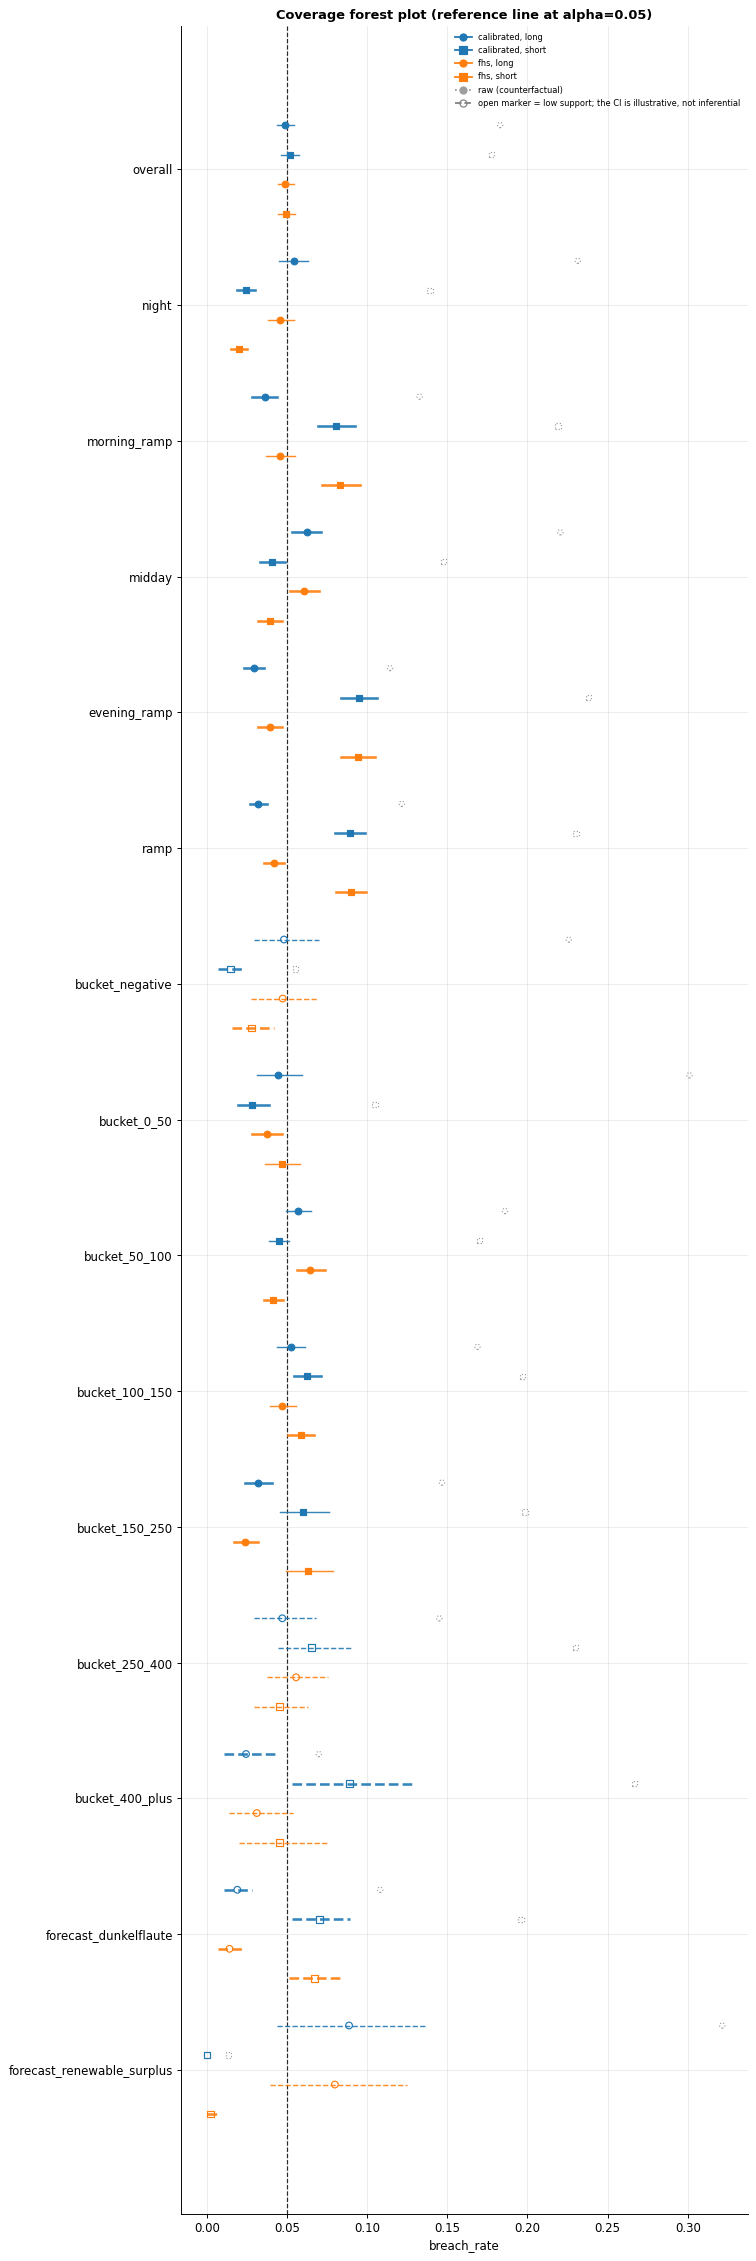

In [21]:
_alpha = 1.0 - backtest_config.level
fig_f6 = plot_coverage_forest(backtest_coverage, alpha=_alpha)

**Figure 6 -- the signature figure of the model validation** (source: `backtest_coverage.csv`, all 60 validated cells + the `raw` counterfactual). `overall` sits on the reference line; a large share of the conditional rows do not. This single figure carries the notebook's thesis: unconditional calibration and conditional calibration are different claims, and the gap between them is exactly what this figure makes visible.

In [22]:
t6 = backtest_coverage[
    backtest_coverage["subset"].isin(["evening_ramp", "forecast_dunkelflaute", "forecast_renewable_surplus"])
    & (backtest_coverage["variant"] != "raw")
][["variant", "side", "subset", "n", "breach_rate", "breach_rate_ci_low", "breach_rate_ci_high", "z1", "low_support"]].reset_index(drop=True)


def _style_low_support_rows(row: pd.Series) -> list[str]:
    style = "color: #9e9e9e; font-style: italic;" if bool(row["low_support"]) else ""
    return [style] * len(row)


HTML(
    t6.style.set_uuid("t6")
    .apply(_style_low_support_rows, axis=1)
    .set_caption("grey/italic = low_support (CI illustrative, not inferential) -- never dropped, spec 4.5 2.4")
    .to_html()
)

,variant,side,subset,n,breach_rate,breach_rate_ci_low,breach_rate_ci_high,z1,low_support
0,calibrated,long,evening_ramp,4884,0.029279,0.023029,0.035831,-0.173459,False
1,calibrated,long,forecast_dunkelflaute,3266,0.018983,0.010932,0.028334,-0.244462,True
2,calibrated,long,forecast_renewable_surplus,451,0.088692,0.043795,0.136461,0.257543,True
3,calibrated,short,evening_ramp,4884,0.094799,0.083538,0.106061,0.048824,False
4,calibrated,short,forecast_dunkelflaute,3266,0.070423,0.053313,0.089427,0.105360,True
5,calibrated,short,forecast_renewable_surplus,451,0.000000,0.000000,0.000000,nan,True
6,fhs,long,evening_ramp,4884,0.039312,0.031941,0.046888,0.001496,False
7,fhs,long,forecast_dunkelflaute,3266,0.014085,0.006695,0.022798,-0.179834,True
8,fhs,long,forecast_renewable_surplus,451,0.079823,0.039500,0.124755,0.662435,True
9,fhs,short,evening_ramp,4884,0.094390,0.083538,0.104832,0.127382,False


**T6** (source: `backtest_coverage.csv`). Directional read: `forecast_dunkelflaute` stresses the **short** book (breach rate 0.067-0.070 vs. ~0.05 overall -- scarcity, upward price spikes); `forecast_renewable_surplus` stresses the **long** book (breach rate 0.080-0.089 -- negative-price crashes) and leaves the short book almost untouched. The z1 difference for the short side in the evening ramp between calibrated and fhs is significant. fhs is under-covering here.

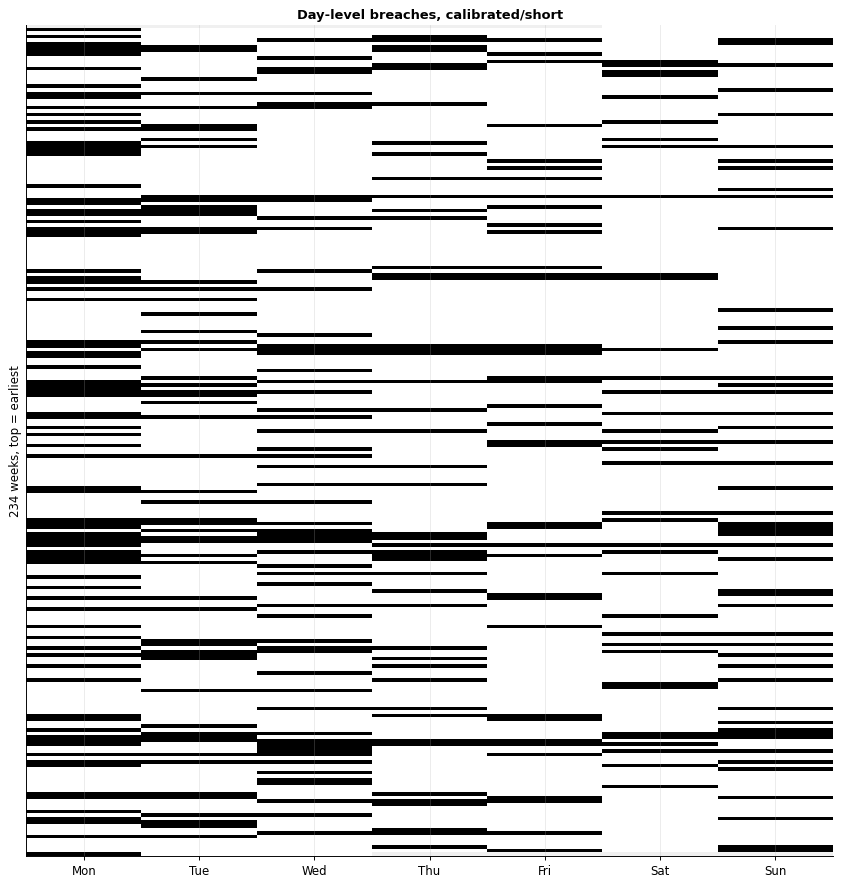

In [23]:
_calibrated_short = risk_hourly[(risk_hourly["variant"] == "calibrated") & (risk_hourly["side"] == "short")].set_index("timestamp")["breach"]
_day_breach = day_breach_series(_calibrated_short, k=backtest_config.day_breach_k, local_tz=LOCAL_TZ)
fig_f7 = plot_breach_calendar(_day_breach.astype(float), title="Day-level breaches, calibrated/short")

In [24]:
_lr_day = backtest_coverage[
    (backtest_coverage["variant"] == "calibrated") & (backtest_coverage["side"] == "short") & (backtest_coverage["subset"] == "overall")
]["chris_ind_lr_day"].iloc[0]
print(f"Christoffersen LR_ind (day series, calibrated/short) = {_lr_day:.1f}  (chi2_1 critical value = 3.84)")

Christoffersen LR_ind (day series, calibrated/short) = 82.0  (chi2_1 critical value = 3.84)


**Figure 7** (source: `risk_hourly.parquet`, `evaluation.backtest.day_breach_series` applied to the calibrated/short breach column -- a grouping, not a new statistic). The multi-day black clusters ARE the LR_ind of 53-104 printed above, made visible: breach days do not scatter randomly, they run in streaks.

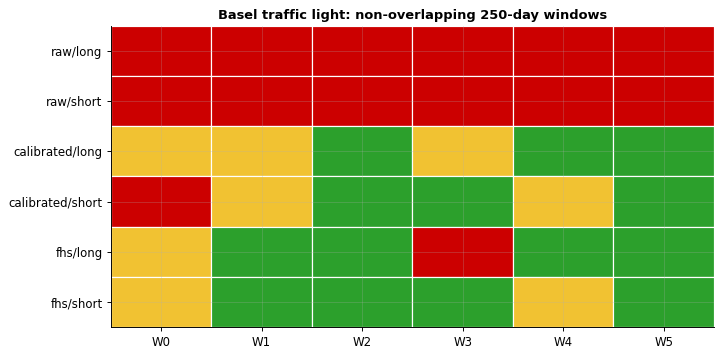

In [25]:
fig_f8 = plot_basel_traffic_light(backtest_basel_windows)

**Figure 8** (source: `backtest_basel_windows.csv`, `backtest.py`'s `basel_traffic_light`). Illustrative, not a regulatory verdict: zone bounds use a 95%/hourly convention here, not the canonical 99%/250-day Basel mapping, and they assume independent hours -- which this book's intra-day breach clustering violates, so a well-calibrated model still trips yellow more than its nominal rate (the overdispersion caveat -- see `basel_traffic_light`'s docstring).

**The arc.** Three findings that look like separate footnotes are one mechanism. The evening
ramp (Figure 6) is the sharpest single expression of conditional heteroskedasticity -- risk
underestimated by nearly a factor of 2 in exactly the hours the book is most exposed. Day-level
breach clustering (Figure 7, `LR_ind`=53-104) is the same conditional structure seen from the
independence-test angle: the 90-day conformal correction fixes the unconditional scale, not the
day-to-day persistence. And the Basel traffic light running yellow/red far more than its
nominal ~5% (Figure 8) is the SAME clustering seen a third way, through a regulatory lens --
overdispersion is what breach clustering looks like to a binomial zone-boundary test. One
mechanism, three symptoms, three independent measurements landing on the same conclusion.

## 8. How much of this survives scrutiny?

**We attacked our own assumptions and put a number on what they cost.**

**The honest test against the convenient one.** Kupiec rejects 43 of 60 cells; the
day-block-bootstrap CI rejects 35 -- and all 35 are a strict subset of the 43 (zero rejections
in the other direction). That is exactly the anti-conservatism signature the hourly-chi-square
caveat predicts: Kupiec runs on the hourly series, where intra-day breaches are correlated, so
it over-rejects relative to the honest, day-block-bootstrapped test. Scale check: 60 tests at
5% would produce ~3 false rejections under a global null; 35-43 is more than an order of
magnitude above that, far too many to be testing-multiplicity noise -- though the 60 cells are
not independent tests (subsets nest and overlap), so no formal correction is attempted, only
named.

**The Basel lesson.** `basel_worst_zone` (a maximum over ~37,800 overlapping rolling windows)
said red on all four (variant, side) combinations; `basel_latest_zone` (the convention Basel
actually means -- a state measure over the last window, not a max over history) says green on
all four. Same data, two verdicts. The generalisation: for any "worst case over N repeats"
number, ask first whether N is independent observations or just many views of the same few.

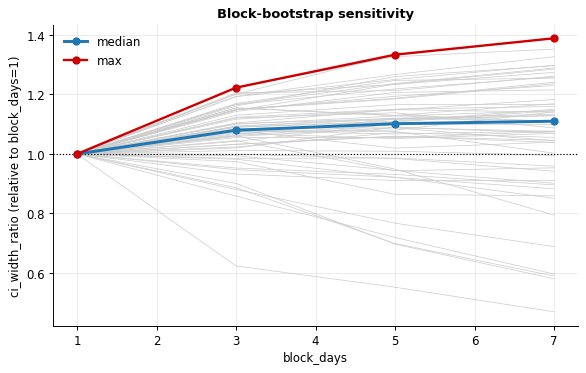

In [26]:
fig_f9 = plot_block_sensitivity(backtest_block_sensitivity_coverage)

In [27]:
_ratio_k7 = backtest_block_sensitivity_coverage.loc[
    backtest_block_sensitivity_coverage["block_days"] == 7, "ci_width_ratio"
].median()
_variance_inflation = _ratio_k7**2
_ess_fraction = 1.0 / _variance_inflation
print(f"median ci_width_ratio at block_days=7: {_ratio_k7:.2f}")
print(f"-> variance inflation: {_variance_inflation:.2f}")
print(f"-> effective sample size: {_ess_fraction:.2f} of nominal (costs {(1 - _ess_fraction) * 100:.0f}%)")

median ci_width_ratio at block_days=7: 1.11
-> variance inflation: 1.23
-> effective sample size: 0.81 of nominal (costs 19%)


**Figure 9** (source: `backtest_block_sensitivity_coverage.csv`, `backtest_block_sensitivity.py`). This is
the statistically most mature statement in this notebook, and it belongs prominently, not
in a footnote: **the daily Christoffersen test says the day-to-day dependence EXISTS** (`LR_ind`
53-104, far past the chi2_1 critical value of 3.84); **the block bootstrap says how much it
costs** -- a ~19% loss of effective sample size at `block_days=7`, real, measured, and decisive
in exactly zero headline findings (`overall` never flips, `evening_ramp` never flips, the
`calibrated`-vs-`fhs` evening-ramp severity contrast never flips). Significance is not effect
size: the chi-square scales with `n`, and at ~1,780 test days even a mild dependence produces a
crushing `LR`.

## 9. Verdict, limitations, future work

**Recommendation: `calibrated` (= `calibrated_sorted`) for production**, not because it wins
every comparison, but because of the book's actual exposure profile:

- **For it:** in the evening ramp / short, `calibrated`'s ES severity is significantly better
  than `fhs`'s (`d_es_ratio` = -0.079, CI [-0.128, -0.032], excludes 0 entirely) -- and this
  finding survived the block-bootstrap sensitivity check at `block_days` 1, 3, 5 AND 7
  (Figure 9). The evening ramp is a *daily* event; it dominates the book's exposure.
- **For it:** `calibrated` is the only variant whose threshold is directly evidenced against
  realised prices (`rearrangement.py`: `q05_calibrated_sorted` coverage = 0.050 against nominal 0.05). `fhs`
  additionally relies on a distributional assumption (see `risk.py`'s `fhs` variant).
- **Against it (stated honestly):** `fhs` is clearly better at the 400+ forecast-height bucket (summed
  deviation 0.101 vs. 0.192). Per bucket, `calibrated_sorted`
  wins 4 of 7 -- but `fhs` wins exactly at the most dangerous edge.
- **Arguable:** `fhs` sits closer to 0 in the unconditional `z1`. `calibrated` is
  mildly conservative there, with a `z1` CI entirely below 0. So unbiasedness would be better before adding safety margins.
- **The tipping condition:** a book that loses money in rare high-price spikes should run
  `fhs`. A book that has to survive the evening ramp every single day should run `calibrated`.
  This is a statement about the book's exposure profile, not about which model is "better" --
  and that is the honest way to phrase a risk-measure choice, as opposed to a metric
  comparison.

**Open limitations, without polish:**

- Conditional coverage in the evening ramp is broken; the fix (a ramp term in the sigma scale)
  is future work, not attempted here.
- Day-level breach clustering survives the conformal correction; the correction was never
  designed to remove it.
- The Basel zone boundaries are binomial and therefore too tight for this book; day-based zone
  boundaries are future work.
- The bootstrap CIs are somewhat too narrow; the size of the effect is now measured (~19%
  effective-sample-size loss at `block_days=7`), not fixed.
- One cell (`calibrated/short/forecast_renewable_surplus`) never converges, by construction:
  zero breaches means `z1` is `NaN` on every possible bootstrap replicate. A structural edge
  case, not a numerical problem.

**What carries forward.** Into the dashboard: the confidence band from
`calibrated_sorted` (Figure 3's calibrated row), the regime filter built on the `regimes.py` flags
(Figure 1's x-axis), and the historical point-accuracy comparison (T1). The plot library above
was written pure and typed for exactly this reason -- every function here returns a `Figure`
and can be handed to `st.pyplot(fig)` unchanged.